### Environment Setup & Data Downloading
In this cell, we set up the Kaggle API token, download the competition dataset, and unzip it. We also import all the necessary libraries and check for GPU availability.


In [7]:
import os

# Set your API token (replace with your exact string if needed)
# pls your own key this key is wrong so you have too
#  you can get the key in kaggle settings 
os.environ['KAGGLE_API_TOKEN'] = 'KGAT_6c242d9325c131b4fcf8bijitjibjtijtijbitjboitjbiojtibj17b1cb5fbd4b'

# 1. Install the kaggle tool
!pip install kaggle --quiet

# 2. Download the competition dataset
!kaggle competitions download -c histopathologic-cancer-detection

# 3. Unzip the files into a folder named 'cancer_data'
# Note: This is a large dataset (~6GB), so extraction will take a few minutes. have to wait 
!unzip -q histopathologic-cancer-detection.zip -d cancer_data

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms, models
from PIL import Image
import pandas as pd
import numpy as np
import os


# basically cheacking the we have gpu or not 
# recommanded gpu othervise you have too wait ages
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using: {device}")

100%|███████████████████████████████████████| 6.31G/6.31G [00:36<00:00, 185MB/s]

Using: cuda


### Data Splitting and DataLoader Initialization
Here we split our initial CSV file into training and validation sets, and save them. We then create our initial PyTorch `DataLoader`s to feed the data into our model.


In [25]:
import os, pandas as pd
from sklearn.model_selection import train_test_split

# path of the dataset and all thing 
CSV_PATH = "/home/zeus/content/cancer_data/train_labels.csv"
IMG_DIR  = "/home/zeus/content/cancer_data/train/"

# Quick verify
df       = pd.read_csv(CSV_PATH)
first_id = df.iloc[0]["id"]
path     = IMG_DIR + first_id + ".tif"
print("File exists:", os.path.exists(path))  # must say True

# Split the datset 
train_df, val_df = train_test_split(
    df, test_size=0.2,
    stratify=df["label"],
    random_state=42
)
train_df.to_csv("train_split.csv", index=False)
val_df.to_csv("val_split.csv",   index=False)

# Datasets we are saving this 
train_dataset = CancerDataset("train_split.csv", IMG_DIR, train_transform)
val_dataset   = CancerDataset("val_split.csv",   IMG_DIR, val_transform)

# Loaders
train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True,
                           num_workers=4, pin_memory=True, prefetch_factor=2)
val_loader   = DataLoader(val_dataset,   batch_size=256, shuffle=False,
                           num_workers=4, pin_memory=True)

print(f"Train: {len(train_dataset)} images")
print(f"Val:   {len(val_dataset)} images")
print("Ready!")

File exists: True
Train: 176020 images
Val:   44005 images
Ready!


### Custom PyTorch Dataset
This cell defines a custom PyTorch `Dataset` called `CancerDataset`. It handles loading the images from disk and fetching their corresponding labels.


In [26]:
class CancerDataset(Dataset):
    # we made the class so we can use the direct if any error happeend we will know from it 

    def __init__(self, csv_file, img_dir, transform=None):
        self.df        = pd.read_csv(csv_file)   # load labels CSV
        self.img_dir   = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    # when anyone try to itreate the object this method will  call

    def __getitem__(self, idx):
        row      = self.df.iloc[idx]
        img_path = os.path.join(self.img_dir, row["id"] + ".tif")
        image    = Image.open(img_path).convert("RGB")
        label    = int(row["label"])           # 0=no cancer, 1=cancer

        if self.transform:
            image = self.transform(image)

        return image, label

### Data Augmentation
We define torchvision transforms to apply data augmentation to our training set (flips, rotations, color jitter) and basic normalizations for both training and validation sets.


In [27]:
# transforming the images so we can do things on it 
train_transform = transforms.Compose([
    transforms.Resize((96, 96)),           # images are already 96x96
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                           [0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((96, 96)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                           [0.229, 0.224, 0.225])
])

### Data Augmentation
We define torchvision transforms to apply data augmentation to our training set (flips, rotations, color jitter) and basic normalizations for both training and validation sets.


In [28]:
import pandas as pd
from sklearn.model_selection import train_test_split

CSV_PATH = "cancer_data/train_labels.csv"
IMG_DIR  = "cancer-detection/train/"
import pandas as pd, os

df       = pd.read_csv(CSV_PATH)
first_id = df.iloc[0]["id"]
path     = IMG_DIR + first_id + ".tif"

print("CSV rows:   ", len(df))
print("First ID:   ", first_id)
print("Full path:  ", path)
print("File exists:", os.path.exists(path))
# Read full CSV and split 80% train / 20% val
full_df = pd.read_csv(CSV_PATH)
train_df, val_df = train_test_split(full_df, test_size=0.2,
                                      stratify=full_df["label"],
                                      random_state=42)

# Save splits to temp CSVs
train_df.to_csv("train_split.csv", index=False)
val_df.to_csv("val_split.csv",   index=False)

# # Create datasets
# train_dataset = CancerDataset("train_split.csv", IMG_DIR, train_transform)
# val_dataset   = CancerDataset("val_split.csv",   IMG_DIR, val_transform)

# Create loaders (batch_size=64 works well on Kaggle GPU)
train_loader = DataLoader(
    train_dataset,
    batch_size=256,        # was 64 — 4x bigger batches
    shuffle=True,
    num_workers=4,         # was 2 — more parallel loading
    pin_memory=True,       # faster CPU→GPU transfer
    prefetch_factor=2      # preload next batch while GPU trains
)

val_loader = DataLoader(
    val_dataset,
    batch_size=256,
    shuffle=False,
    num_workers=4,
    pin_memory=True
)

print(f"Train batches: {len(train_loader)}")
print(f"Val batches:   {len(val_loader)}")

CSV rows:    220025
First ID:    f38a6374c348f90b587e046aac6079959adf3835
Full path:   cancer-detection/train/f38a6374c348f90b587e046aac6079959adf3835.tif
File exists: False
Train batches: 688
Val batches:   172


### Model Definition (ResNet18)
We load a pre-trained ResNet18 model, freeze its base layers, and replace the fully connected head with a new sequence of layers for binary classification (Cancer vs. No Cancer).


In [29]:
model = models.resnet18(pretrained=True)

for param in model.parameters():
    param.requires_grad = False       # freeze all layers

num_features = model.fc.in_features
model.fc = nn.Sequential(
    nn.Linear(num_features, 256),
    nn.ReLU(),
    nn.Dropout(0.4),
    nn.Linear(256, 2)               # 2 outputs: cancer / no cancer
)

model = model.to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.fc.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.5)


/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


### Training Loop
This cell contains the main training loop. It iterates over the data for multiple epochs using mixed precision (for speed), calculates the loss, updates the model weights, and runs validation at the end of each epoch to save the best model.


In [30]:
from torch.cuda.amp import GradScaler, autocast

scaler     = GradScaler()   # handles mixed precision math
EPOCHS     = 5
best_val   = 0

for epoch in range(EPOCHS):

    # ── Training ──────────────────────────
    model.train()
    correct = total = running_loss = 0

    for i, (images, labels) in enumerate(train_loader):
        images = images.to(device, non_blocking=True)  # non_blocking = async transfer
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)  # faster than zero_grad()

        with autocast():                        # use float16 on GPU
            outputs = model(images)
            loss    = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item()
        _, predicted  = outputs.max(1)
        total        += labels.size(0)
        correct      += predicted.eq(labels).sum().item()

        if (i+1) % 50 == 0:
            print(f"  [{i+1}/{len(train_loader)}] loss: {running_loss/(i+1):.3f}")

    train_acc = 100 * correct / total

    # ── Validation ────────────────────────
    model.eval()
    val_correct = val_total = 0

    with torch.no_grad():
        with autocast():                        # also use float16 in val
            for images, labels in val_loader:
                images = images.to(device, non_blocking=True)
                labels = labels.to(device, non_blocking=True)
                outputs     = model(images)
                _, predicted = outputs.max(1)
                val_total   += labels.size(0)
                val_correct += predicted.eq(labels).sum().item()

    val_acc = 100 * val_correct / val_total
    scheduler.step()

    if val_acc > best_val:
        best_val = val_acc
        torch.save(model.state_dict(), "best_model.pth")
        print(f"  ✓ best model saved ({best_val:.1f}%)")

    print(f"Epoch [{epoch+1}/{EPOCHS}]  train: {train_acc:.1f}%  val: {val_acc:.1f}%")

print(f"\nDone. Best val: {best_val:.1f}%")

/tmp/ipykernel_9332/3035739.py:3: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler     = GradScaler()   # handles mixed precision math
/tmp/ipykernel_9332/3035739.py:19: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():                        # use float16 on GPU


  [50/688] loss: 0.496
  [100/688] loss: 0.461
  [150/688] loss: 0.447
  [200/688] loss: 0.438
  [250/688] loss: 0.431
  [300/688] loss: 0.426
  [350/688] loss: 0.421
  [400/688] loss: 0.417
  [450/688] loss: 0.414
  [500/688] loss: 0.412
  [550/688] loss: 0.409
  [600/688] loss: 0.407
  [650/688] loss: 0.404


/tmp/ipykernel_9332/3035739.py:42: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():                        # also use float16 in val


  ✓ best model saved (85.1%)
Epoch [1/5]  train: 82.0%  val: 85.1%
  [50/688] loss: 0.371
  [100/688] loss: 0.378
  [150/688] loss: 0.377
  [200/688] loss: 0.376
  [250/688] loss: 0.376
  [300/688] loss: 0.378
  [350/688] loss: 0.378
  [400/688] loss: 0.376
  [450/688] loss: 0.377
  [500/688] loss: 0.377
  [550/688] loss: 0.377
  [600/688] loss: 0.376
  [650/688] loss: 0.376
  ✓ best model saved (85.5%)
Epoch [2/5]  train: 83.5%  val: 85.5%
  [50/688] loss: 0.365
  [100/688] loss: 0.363
  [150/688] loss: 0.362
  [200/688] loss: 0.365
  [250/688] loss: 0.363
  [300/688] loss: 0.363
  [350/688] loss: 0.362
  [400/688] loss: 0.363
  [450/688] loss: 0.363
  [500/688] loss: 0.363
  [550/688] loss: 0.362
  [600/688] loss: 0.362
  [650/688] loss: 0.363
  ✓ best model saved (86.0%)
Epoch [3/5]  train: 84.1%  val: 86.0%
  [50/688] loss: 0.354
  [100/688] loss: 0.358
  [150/688] loss: 0.359
  [200/688] loss: 0.356
  [250/688] loss: 0.353
  [300/688] loss: 0.354
  [350/688] loss: 0.353
  [400/688

### Load Best Model
After training, we load the weights of the best performing model from the training phase for inference.


In [31]:
# Load the best model we saved during training
model.load_state_dict(torch.load("best_model.pth", map_location=device))
model.eval()   # switch to prediction mode — no dropout, no learning
print("Model loaded and ready!")

Model loaded and ready!


### Inference Function
This helper function takes an image path, applies the necessary transformations, passes it through the model, and returns the prediction and confidence score.


In [3]:
def predict_image(img_path):
    # Step 1: open the image
    image = Image.open(img_path).convert("RGB")

    # Step 2: apply same transforms as training
    tensor = val_transform(image)         # shape: [3, 96, 96]
    tensor = tensor.unsqueeze(0)          # shape: [1, 3, 96, 96] — add batch dim
    tensor = tensor.to(device)

    # Step 3: run through model
    with torch.no_grad():
        outputs     = model(tensor)            # raw scores [cancer, no_cancer]
        probs       = torch.nn.functional.softmax(outputs, dim=1)  # convert to %
        confidence, predicted = probs.max(1)   # highest probability + its index

    label      = "CANCER" if predicted.item() == 1 else "NO CANCER"
    confidence = confidence.item() * 100

    return image, label, confidence, probs[0].tolist()

### Single Image Prediction
We pick a single sample from the validation set, run our prediction function on it, and display the image alongside its prediction confidence.


In [4]:
import matplotlib.pyplot as plt

# ── Correct path (fixed) ──────────────────────────────
IMG_DIR = "/home/zeus/content/cancer_data/train/"

# ── Pick an image ─────────────────────────────────────
idx        = 1                              # change this to any number
sample_id  = val_df.iloc[idx]["id"]
true_label = val_df.iloc[idx]["label"]   # fixed: was using [0] always
img_path   = IMG_DIR + sample_id + ".tif"

# ── Run prediction ────────────────────────────────────
image, label, confidence, probs = predict_image(img_path)

# ── Display ───────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].imshow(image)
axes[0].axis("off")
axes[0].set_title(f"Input image\nTrue label: {'Cancer' if true_label==1 else 'No Cancer'}",
                   fontsize=11)

colors = ["#2ecc71", "#e74c3c"]
bars   = axes[1].barh(
    ["No Cancer", "Cancer"],
    [probs[0] * 100, probs[1] * 100],
    color=colors, height=0.4
)
axes[1].set_xlim(0, 100)
axes[1].set_xlabel("Confidence (%)")
axes[1].set_title(
    f"Prediction: {label}\nConfidence: {confidence:.1f}%",
    fontsize=11,
    color="red" if label == "CANCER" else "green"
)

for bar, prob in zip(bars, probs):
    axes[1].text(prob * 100 + 1,
             bar.get_y() + bar.get_height() / 2,
             f"{prob*100:.1f}%", va="center", fontsize=10)

plt.tight_layout()
plt.show()

NameError: name 'val_df' is not defined

### Grid Prediction
Here we run predictions on a batch of 9 images and visualize them in a 3x3 grid, highlighting correct predictions in green and incorrect ones in red.


NameError: name 'val_df' is not defined

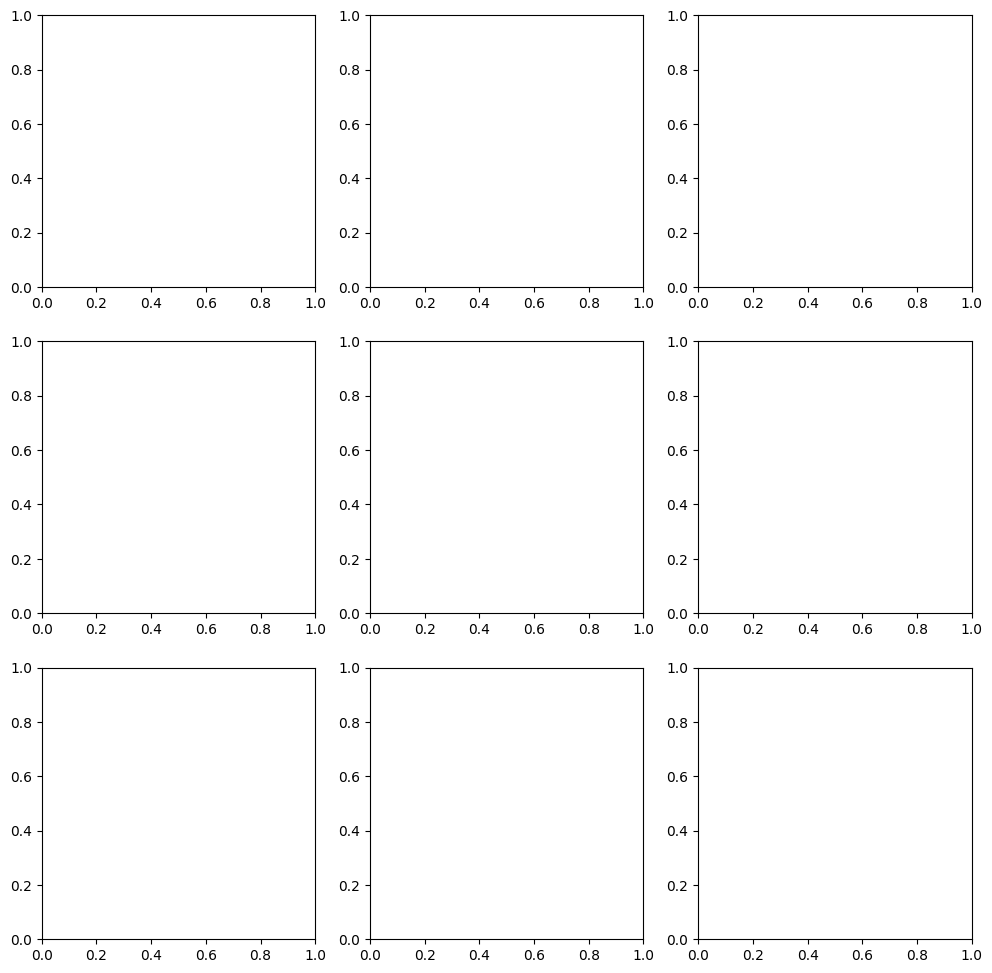

In [5]:
IMG_DIR = "/home/zeus/content/cancer_data/train/"

fig, axes = plt.subplots(3, 3, figsize=(12, 12))
axes = axes.flatten()

for i in range(9):
    row        = val_df.iloc[i]
    img_path   = IMG_DIR + row["id"] + ".tif"
    true_label = "Cancer" if row["label"] == 1 else "Normal"

    image, pred_label, confidence, _ = predict_image(img_path)

    correct = (pred_label == "CANCER") == (row["label"] == 1)
    color   = "green" if correct else "red"

    axes[i].imshow(image)
    axes[i].axis("off")
    axes[i].set_title(
        f"True: {true_label}\nPred: {pred_label} ({confidence:.0f}%)",
        fontsize=9, color=color
    )

    # fixed: spines not spines()
    for spine in axes[i].spines.values():
        spine.set_edgecolor(color)
        spine.set_linewidth(3)
        spine.set_visible(True)

plt.suptitle("Green = correct  |  Red = wrong", fontsize=12)
plt.tight_layout()
plt.show()